In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#Prepare Dataset

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
#Adding noise
def add_noise(img, noise_factor=0.5):#noise factor is a scaling coefficient, increase/decrease amount of noise
    noisy = img + noise_factor * torch.randn_like(img) #torch.randn_like(img) generates random values ~ N(0,1) (mean 0, std 1), it is a tensor of the same shape as img
    noisy = torch.clamp(noisy, 0., 1.) #noisy images may have values below 0 and above 1, this function fixes this by clipping values to [0,1]
    return noisy

In [ ]:
# Autoencoder model
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),#first layer
            nn.ReLU(),
            nn.Linear(256, 64),#code/bottleneck layer
            nn.ReLU()
        )

#Input image is now represented as 64-dimensional vector

        self.decoder = nn.Sequential(
            nn.Linear(64, 256),  #Maps the 64-dimensional bottleneck vector back to 256 features(first step of reconstruction)
            nn.ReLU(),
            nn.Linear(256, 28*28), #Maps 256 features back to the original input dimension (the output is a flat vector representing the reconstructed image)
            nn.Sigmoid() #maps values between 0 and 1, matching the input image pixel range
        )



    def forward(self, x):
        encoded = self.encoder(x)  #Compress
        decoded = self.decoder(encoded) #reconstruction
        decoded = decoded.view(-1, 1, 28, 28) #Reshape to image format (batch_size, channels, height, width)
        return decoded



In [ ]:
model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)



In [ ]:
# Training loop
epochs = 5

for epoch in range(epochs):
    for img, _ in train_loader:
        img = img.to(device)

        noisy_img = add_noise(img)

        output = model(noisy_img)

        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")



Epoch [1/5], Loss: 0.0346
Epoch [2/5], Loss: 0.0260
Epoch [3/5], Loss: 0.0240
Epoch [4/5], Loss: 0.0215
Epoch [5/5], Loss: 0.0177


In [ ]:
#Testing
dataiter = iter(test_loader) #creates a Python iterator over the batches.
images, _ = next(dataiter) #next() gets the next batch from the iterator and - ignores labels.

noisy_imgs = add_noise(images).to(device)
outputs = model(noisy_imgs).cpu().detach() #matplotlib cannot handle GPU tensors, This function Denoise & move results back to CPU for plotting

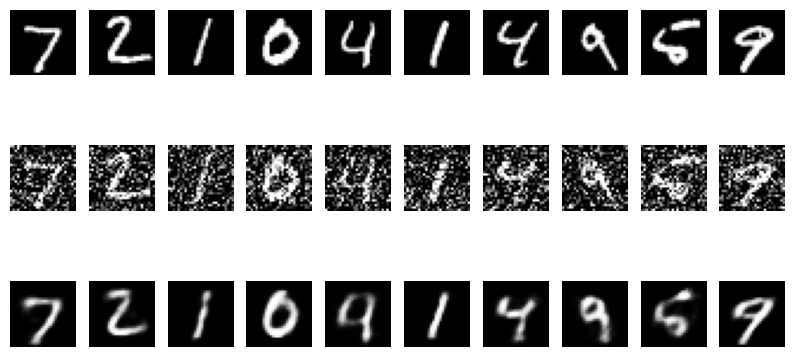

In [ ]:


# display images
fig, axes = plt.subplots(3, 10, figsize=(10,5))

for i in range(10):
    axes[0,i].imshow(images[i].squeeze(), cmap="gray") #squeeze() removes the channel dimension because imshow expects 2D
    axes[0,i].axis("off")

    axes[1,i].imshow(noisy_imgs.cpu()[i].squeeze(), cmap="gray")
    axes[1,i].axis("off")

    axes[2,i].imshow(outputs[i].squeeze(), cmap="gray")
    axes[2,i].axis("off")

axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Noisy")
axes[2,0].set_ylabel("Denoised")

plt.show()

### Convolutional Denoising Autoencoder (ConvEncoder)


In [ ]:
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(ConvDenoisingAutoencoder, self).__init__()

        # Encoder layers
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), # Input: (batch, 1, 28, 28) -> (batch, 16, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # -> (batch, 16, 14, 14)

            nn.Conv2d(16, 8, kernel_size=3, padding=1),  # -> (batch, 8, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # -> (batch, 8, 7, 7) - Bottleneck
        )

        # Decoder layers
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=2, stride=2), # Input: (batch, 8, 7, 7) -> (batch, 16, 14, 14)
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2), # -> (batch, 1, 28, 28)
            nn.Sigmoid() # Output pixels between 0 and 1
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Instantiate the new convolutional autoencoder
conv_model = ConvDenoisingAutoencoder().to(device)

criterion_conv = nn.MSELoss()
optimizer_conv = optim.Adam(conv_model.parameters(), lr=1e-3)

In [ ]:
# Training loop for ConvDenoisingAutoencoder
epochs_conv = 5

print("\n--- Training Convolutional Denoising Autoencoder ---")
for epoch in range(epochs_conv):
    for img, _ in train_loader:
        img = img.to(device)

        noisy_img = add_noise(img)

        output = conv_model(noisy_img)

        loss = criterion_conv(output, img)

        optimizer_conv.zero_grad()
        loss.backward()
        optimizer_conv.step()

    print(f"Epoch [{epoch+1}/{epochs_conv}], Loss: {loss.item():.4f}")


--- Training Convolutional Denoising Autoencoder ---
Epoch [1/5], Loss: 0.0319
Epoch [2/5], Loss: 0.0222
Epoch [3/5], Loss: 0.0206
Epoch [4/5], Loss: 0.0220
Epoch [5/5], Loss: 0.0194


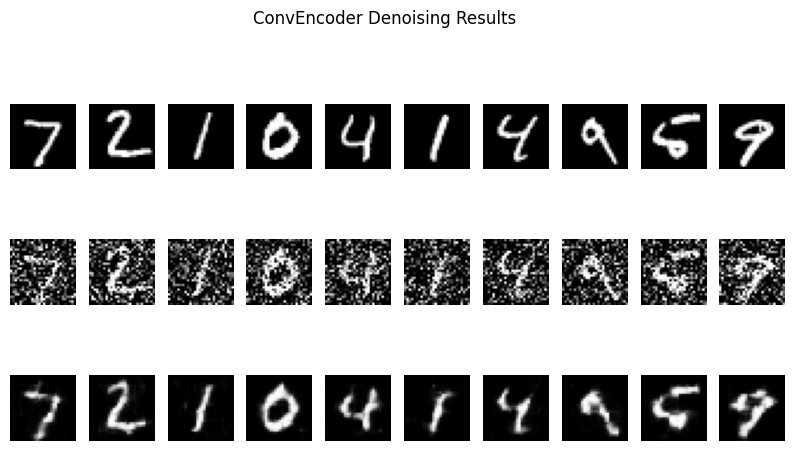

In [ ]:
# Testing and Visualization for ConvDenoisingAutoencoder

dataiter_conv = iter(test_loader)
images_conv, _ = next(dataiter_conv)

noisy_imgs_conv = add_noise(images_conv).to(device)
outputs_conv = conv_model(noisy_imgs_conv).cpu().detach()

# Display images
fig_conv, axes_conv = plt.subplots(3, 10, figsize=(10,5))

for i in range(10):
    axes_conv[0,i].imshow(images_conv[i].squeeze(), cmap="gray")
    axes_conv[0,i].axis("off")

    axes_conv[1,i].imshow(noisy_imgs_conv.cpu()[i].squeeze(), cmap="gray")
    axes_conv[1,i].axis("off")

    axes_conv[2,i].imshow(outputs_conv[i].squeeze(), cmap="gray")
    axes_conv[2,i].axis("off")

axes_conv[0,0].set_ylabel("Original")
axes_conv[1,0].set_ylabel("Noisy")
axes_conv[2,0].set_ylabel("Denoised")

plt.suptitle("ConvEncoder Denoising Results", y=1.02) # Add a main title
plt.show()